# DMI benchmark problem in 1D
Implementation of the 1D problem proposed in David Cortés-Ortuño et al 2018 New J. Phys. 20 113015.

## Simulation
### Import libraries
Import libraries and set default precision to double to guarantee convergence.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import sys

import neuralmag as nm

repo_root = Path.cwd().resolve()
if not (repo_root / "demos").exists():
    for parent in repo_root.parents:
        if (parent / "demos").exists():
            repo_root = parent
            break
sys.path.insert(0, str(repo_root / "demos"))

from _static_method_compare import SOLVER_LABELS, compare_static_methods, print_static_method_summary

nm.config.dtype = "float64"

2026-04-22 12:20:51 NeuralMag:INFO [NeuralMag] Version 0.9.4
2026-04-22 12:20:52 NeuralMag:INFO [NeuralMag] Backend set to 'jax'.
2026-04-22 12:20:52 NeuralMag:INFO [NeuralMag] Set default dtype to 'float64'.


### Create mesh and state
Next we set up a state with a 1D mesh object (a mesh with nodes only in the x-direction).

In [2]:
mesh = nm.Mesh((100,), (1e-9, 1e-9, 1e-9))
state = nm.State(mesh)

2026-04-22 12:20:52 NeuralMag:INFO [Mesh] 1D, 100 (size = 1e-09 x 1e-09 x 1e-09)
2026-04-22 12:20:52 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.
2026-04-22 12:21:00 NeuralMag:INFO [State] Running on device: cuda:0 (dtype = float64, backend = jax)


### Material parameters and initial magnetization
The material parameters are set up according to the proposed problem and set an initial magnetization in the z-direction.


In [3]:
state.material.Ms = 0.86e6
state.material.A = 1.3e-11
state.material.Ku = 0.4e6
state.material.Ku_axis = [0, 0, 1]
state.material.Di = 3e-3
state.material.Di_axis = [0, 0, 1]
state.material.alpha = 1.0

state.m = nm.VectorFunction(state).fill((0, 0, 1))

### Effective field and method comparison

Next, we set up the effective field which is comprised of contributions from interface DMI, exchange and uniaxial anisotropy. For this example, we do not explicitly account for the demagnetization field, but rather use an effective anisotropy that also accounts for the shape anisotropy.

To compare the damped-LLG relaxer with the BB steepest-descent minimizer fairly, we rebuild the same initial state for each method before relaxing it into equilibrium.

In [4]:
def build_system():
    mesh = nm.Mesh((100,), (1e-9, 1e-9, 1e-9))
    state = nm.State(mesh)

    state.material.Ms = 0.86e6
    state.material.A = 1.3e-11
    state.material.Ku = 0.4e6
    state.material.Ku_axis = [0, 0, 1]
    state.material.Di = 3e-3
    state.material.Di_axis = [0, 0, 1]
    state.material.alpha = 1.0

    state.m = nm.VectorFunction(state).fill((0, 0, 1))

    nm.InterfaceDMIField().register(state, "dmi")
    nm.ExchangeField().register(state, "exchange")
    nm.UniaxialAnisotropyField().register(state, "aniso")
    nm.TotalField("aniso", "dmi", "exchange").register(state)
    return state

comparison = compare_static_methods(build_system, llg_runner=lambda solver: solver.relax(1e9))
print_static_method_summary("DMI benchmark problem in 1D", comparison)

2026-04-22 12:21:01 NeuralMag:INFO [Mesh] 1D, 100 (size = 1e-09 x 1e-09 x 1e-09)
2026-04-22 12:21:01 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.
2026-04-22 12:21:01 NeuralMag:INFO [State] Running on device: cuda:0 (dtype = float64, backend = jax)
2026-04-22 12:21:01 NeuralMag:INFO [InterfaceDMIField] Register state methods (field: 'h_dmi', energy: 'E_dmi', energy density: 'e_dmi')
2026-04-22 12:21:01 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange', energy density: 'e_exchange')
2026-04-22 12:21:01 NeuralMag:INFO [UniaxialAnisotropyField] Register state methods (field: 'h_aniso', energy: 'E_aniso', energy density: 'e_aniso')
2026-04-22 12:21:01 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E', energy density: 'e')
2026-04-22 12:21:01 NeuralMag:INFO [LLGSolverJAX] Initialize RHS function
2026-04-22 12:21:01 NeuralMag:INFO [LLGSolverJAX] Relaxation started, initial energy E = -4e-20 J
2026-04-22 12:

DMI benchmark problem in 1D method comparison
- LLG relax: runtime = 3.14s, E = -4.204614e-20 J
- BB steepest descent: runtime = 1.44s, E = -4.204674e-20 J, ΔE vs LLG = -5.918e-25 J, BB iterations = 63


## Visualization
We extract the magnetization data from the discretized magnetization field stored in each compared state and plot both minimizers against the analytical reference presented in the original work by Cortés-Ortuño et al.

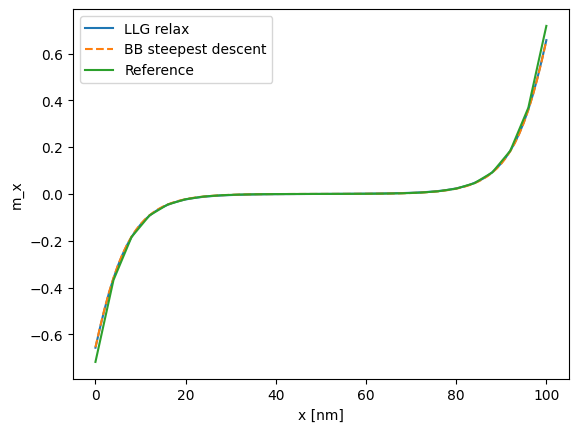

In [5]:
data = {}
for method, values in comparison.items():
    m = nm.config.backend.to_numpy(values["state"].m.tensor)
    data[method] = np.zeros((m.shape[0], 4))
    data[method][:, 0] = np.arange(m.shape[0])
    data[method][:, (1, 2, 3)] = m[:, :]

ref = np.array(
    [
        -7.17885457e-01,
        -3.68028209e-01,
        -1.84133801e-01,
        -9.15314286e-02,
        -4.54233302e-02,
        -2.25310767e-02,
        -1.11735402e-02,
        -5.53930074e-03,
        -2.74312482e-03,
        -1.35264383e-03,
        -6.55428327e-04,
        -2.94184151e-04,
        -8.37557859e-05,
        8.37314816e-05,
        2.94160582e-04,
        6.55405003e-04,
        1.35262473e-03,
        2.74309370e-03,
        5.53925965e-03,
        1.11734897e-02,
        2.25310031e-02,
        4.54232225e-02,
        9.15313263e-02,
        1.84133572e-01,
        3.68027672e-01,
        7.17884296e-01,
    ]
)

plt.plot(data["llg"][:, 0], data["llg"][:, 1], label=SOLVER_LABELS["llg"])
plt.plot(data["bb"][:, 0], data["bb"][:, 1], "--", label=SOLVER_LABELS["bb"])
plt.plot(data["llg"][::4, 0], ref, label="Reference")
plt.legend()
plt.xlabel("x [nm]")
plt.ylabel("m_x")
plt.show()